**Mashalov Rasulbek, OSTC2U, Machine Learning, HomeWork 5, 12th March, 2026**

In [50]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.datasets import fetch_openml
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve, roc_curve
import tensorflow as tf
import numpy as np
import time
import math
import matplotlib.pyplot as plt

**EXERCISE 1**

At first I used Wine dataset, but the model got 100% accuracy, it turns out the dataset is too easy to seperate/memorize, so I had to try another dataset, which has more noise and not easy to memorize, the title is: Pima Indians Diabetes dataset

In [51]:
data = fetch_openml(name='pima-indians-diabetes', version=1, as_frame=True)
print(data.DESCR)

DESCRIPTION
Problem Statement
    NIDDK (National Institute of Diabetes and Digestive and Kidney Diseases) research creates knowledge about and treatments for the most chronic, costly, and consequential diseases.
    The dataset used in this project is originally from NIDDK. The objective is to predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset.
    Build a model to accurately predict whether the patients in the dataset have diabetes or not.
Dataset Description
The datasets consists of several medical predictor variables and one target variable (Outcome). Predictor variables includes the number of pregnancies the patient has had, their BMI, insulin level, age, and more.
Variables    Description
Pregnancies    Number of times pregnant
Glucose    Plasma glucose concentration in an oral glucose tolerance test
BloodPressure    Diastolic blood pressure (mm Hg)
SkinThickness    Triceps skinfold thickness (mm)
Insulin    Two hour se

In [52]:
#data prep+learning rate test
diabetes = fetch_openml(name='diabetes', version=1, as_frame=True, parser='auto')
X = diabetes.data

#converting 'tested_positive' -> 1,'tested_negative' -> 0
y = (diabetes.target == 'tested_positive').astype(int)

#splitting/Scaling the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2021)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"[INFO] Training set size: {X_train_scaled.shape[0]}")

#testing "bad/too high" learning rate
start = time.time()
model_bad = SGDClassifier(loss="log_loss", learning_rate='constant', eta0=10.0, random_state=2021)
model_bad.fit(X_train_scaled, y_train)
pred_bad = model_bad.predict(X_test_scaled)
print("[INFO] Accuracy with learning rate 10.0:  {:.2f}%".format(np.mean(y_test == pred_bad) * 100))

#testing  "good" learning rate
start = time.time()
model_good = SGDClassifier(loss="log_loss", learning_rate='constant', eta0=0.01, random_state=2021)
model_good.fit(X_train_scaled, y_train)
pred_good = model_good.predict(X_test_scaled)
print("[INFO] Accuracy with learning rate 0.01: {:.2f}%".format(np.mean(y_test == pred_good) * 100))

y_scores = model_good.decision_function(X_test_scaled)

[INFO] Training set size: 614
[INFO] Accuracy with learning rate 10.0:  73.38%
[INFO] Accuracy with learning rate 0.01: 76.62%


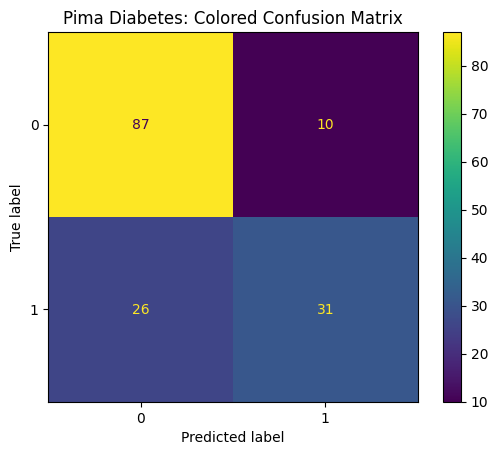

In [53]:
#confusion matrix
disp = ConfusionMatrixDisplay.from_estimator(model_good, X_test_scaled, y_test)
disp.ax_.set_title("Pima Diabetes: Colored Confusion Matrix")
plt.show()

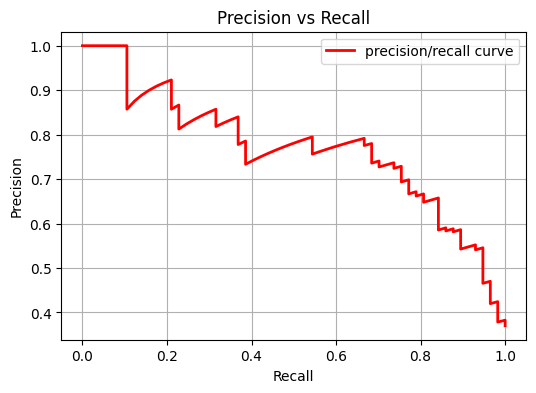

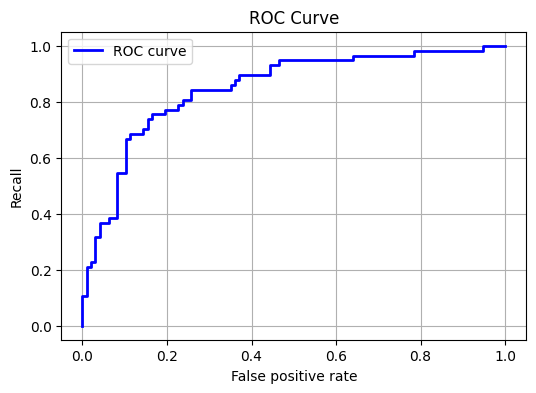

In [54]:
#precision/Recall Curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

def prec_recall_curve(precisions, recalls):
    plt.figure(figsize=(6, 4))
    plt.plot(recalls, precisions, "r", label="precision/recall curve", linewidth=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision vs Recall")
    plt.grid()
    plt.legend()
    plt.show()

prec_recall_curve(precisions, recalls)

#ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_scores)

def plot_roc(tpr, fpr):
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, "b", label="ROC curve", linewidth=2)
    plt.xlabel("False positive rate")
    plt.ylabel("Recall")
    plt.title("ROC Curve")
    plt.grid()
    plt.legend()
    plt.show()

plot_roc(tpr, fpr)

**EXERCISE 2**

In [59]:
#class creation
class MyOneVsAllClassifier:
    def __init__(self, random_state=2021):
        self.models = []
        self.classes_ = []
        self.random_state = random_state

    def fit(self, X, y):
        #auto detecting all unique classes in the dataset
        self.classes_ = np.unique(y)
        self.models = []

        #training separate binary classifier for EACH class
        for cls in self.classes_:
            print(f"[INFO] Training binary classifier for Class {cls}...")

            #creating binary target array: 1 if it is the current class, 0 if it is anything else
            y_binary = (y == cls).astype(int)

            #using 'log_loss' so the model can output probabilities
            model = SGDClassifier(loss="log_loss", learning_rate='constant', eta0=0.01, random_state=self.random_state)
            model.fit(X, y_binary)

            #saving the model
            self.models.append(model)

    def predict(self, X):
        #creating 2D array (rows = samples, columns = classes) to store the probability scores for each sample and each class
        probabilities = np.zeros((X.shape[0], len(self.classes_)))

        #asking confidenence
        for i, model in enumerate(self.models):

            probabilities[:, i] = model.predict_proba(X)[:, 1]

        #finding the index of the highest probability score
        best_indices = np.argmax(probabilities, axis=1)

        return self.classes_[best_indices]

In [60]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

#spliting  the data
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris, test_size=0.2, random_state=2021)

#scaling the data
scaler_iris = StandardScaler()
X_train_iris_scaled = scaler_iris.fit_transform(X_train_iris)
X_test_iris_scaled = scaler_iris.transform(X_test_iris)

print(f"[INFO] Training set size: {X_train_iris_scaled.shape[0]}")

[INFO] Training set size: 120


[INFO] Initiating Custom One-vs-All Training...
[INFO] Training binary classifier for Class 0...
[INFO] Training binary classifier for Class 1...
[INFO] Training binary classifier for Class 2...

[INFO] Custom One-Vs-All Classifier Accuracy: 93.33%


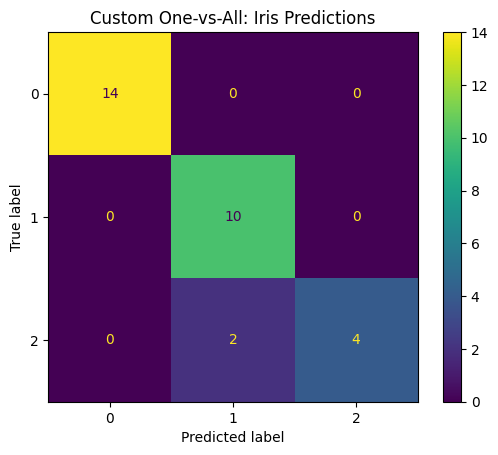

In [61]:
print("[INFO] Initiating Custom One-vs-All Training...")

#training custom model
my_ova_model = MyOneVsAllClassifier(random_state=2021)
my_ova_model.fit(X_train_iris_scaled, y_train_iris)

#making predictions
y_pred_iris = my_ova_model.predict(X_test_iris_scaled)

#calculating accuracy
accuracy = accuracy_score(y_test_iris, y_pred_iris)
print(f"\n[INFO] Custom One-Vs-All Classifier Accuracy: {accuracy * 100:.2f}%")

#confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test_iris, y_pred_iris)
plt.title("Custom One-vs-All: Iris Predictions")
plt.show()